In [2]:
# ============================================
# STEP 1: IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

In [3]:
# # ============================================
# # STEP 2: MOUNT GOOGLE DRIVE
# # ============================================

# from google.colab import drive

# drive.mount('/content/drive')

In [4]:
df = pd.read_csv('../data/crop_yield.csv')

df.head()

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909


In [5]:
# CLEAN ALL CATEGORICAL COLUMNS (IMPORTANT FIX)
cat_cols = ["Crop", "Season", "State"]

for col in cat_cols:
    df[col] = df[col].astype(str).str.strip()

In [6]:
df["Crop"] = df["Crop"].str.title()
df["Season"] = df["Season"].str.title()
df["State"] = df["State"].str.title()

In [7]:
# ============================================
# STEP 4: CHECK MISSING VALUES
# ============================================

df.isnull().sum()

Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
dtype: int64

In [8]:
# ============================================
# STEP 5: REMOVE MISSING VALUES
# ============================================

df = df.dropna()

In [9]:
# ============================================
# STEP 5B: HANDLE YIELD OUTLIERS
# ============================================

df = df[df["Yield"] < df["Yield"].quantile(0.99)]

In [10]:
# ============================================
# STEP 6: CHECK COLUMN NAMES
# ============================================

df.columns

Index(['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Production',
       'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield'],
      dtype='object')

In [11]:
print(df["Season"].unique())

['Whole Year' 'Kharif' 'Rabi' 'Autumn' 'Summer' 'Winter']


In [12]:
# ============================================
# STEP 6: SELECT FEATURES
# ============================================

features = [
    "Crop",
    "Crop_Year",
    "Season",
    "State",
    "Area",
    "Annual_Rainfall",
    "Fertilizer",
    "Pesticide"
]

X = df[features]

y = df["Yield"]

In [13]:
# ============================================
# STEP 7: BUILD PIPELINE WITH PREPROCESSING
# ============================================

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_cols = ["Crop", "Season", "State"]
numerical_cols = ["Crop_Year", "Area", "Annual_Rainfall", "Fertilizer", "Pesticide"]

preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("num", "passthrough", numerical_cols)
])

In [14]:
# ============================================
# STEP 8: TRAIN TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
# ============================================
# STEP 9 & 10: CREATE AND TRAIN PIPELINE
# ============================================

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=100, random_state=42))
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Crop', 'Season', 'State']),
                                                 ('num', 'passthrough',
                                                  ['Crop_Year', 'Area',
                                                   'Annual_Rainfall',
                                                   'Fertilizer',
                                                   'Pesticide'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [16]:
# ============================================
# STEP 11: MAKE PREDICTIONS
# ============================================

y_pred = pipeline.predict(X_test)

In [17]:
# ============================================
# STEP 12: EVALUATE MODEL
# ============================================

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.653280779381244
RMSE: 2.2828765096707206
R2 Score: 0.9565727125108624


In [18]:
train_score = pipeline.score(X_train, y_train)
test_score = pipeline.score(X_test, y_test)

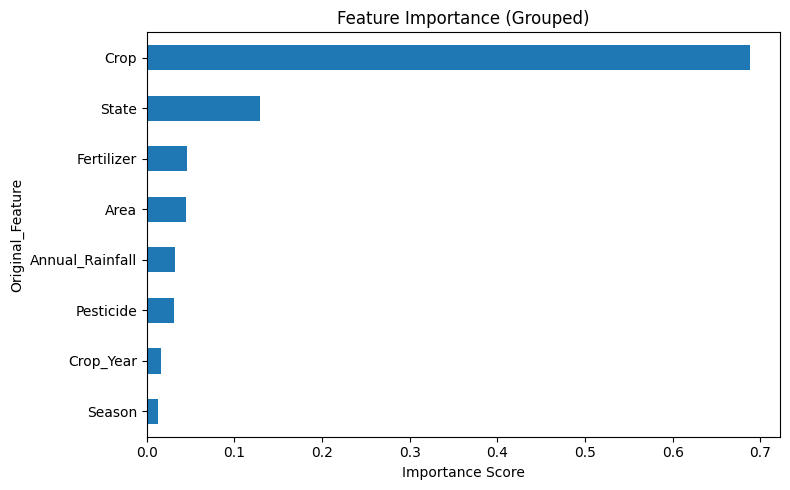

In [19]:
# ============================================
# STEP 13: FEATURE IMPORTANCE
# ============================================

import matplotlib.pyplot as plt

# Get feature names after OneHotEncoding
ohe_feature_names = pipeline.named_steps["preprocessor"]\
    .named_transformers_["cat"]\
    .get_feature_names_out(["Crop", "Season", "State"])

numerical_cols = ["Crop_Year", "Area", "Annual_Rainfall", "Fertilizer", "Pesticide"]

all_feature_names = list(ohe_feature_names) + numerical_cols

# Get RandomForest from inside the pipeline
rf_model = pipeline.named_steps["model"]

importance = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": rf_model.feature_importances_
})

# Group OHE columns back to original feature name
def get_original_feature(name):
    if name.startswith("Crop_") and name != "Crop_Year": return "Crop"
    if name.startswith("Season_"): return "Season"
    if name.startswith("State_"): return "State"
    return name

importance["Original_Feature"] = importance["Feature"].apply(get_original_feature)

grouped_importance = importance.groupby("Original_Feature")["Importance"].sum().reset_index()
grouped_importance = grouped_importance.sort_values(by="Importance", ascending=False)

grouped_importance.sort_values(by="Importance").plot(
    x="Original_Feature", y="Importance", kind="barh", figsize=(8, 5), legend=False
)
plt.title("Feature Importance (Grouped)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [20]:
# Show all unique crop names

df["Crop"].unique()

array(['Arecanut', 'Arhar/Tur', 'Castor Seed', 'Cotton(Lint)',
       'Dry Chillies', 'Gram', 'Jute', 'Linseed', 'Maize', 'Mesta',
       'Niger Seed', 'Onion', 'Other  Rabi Pulses', 'Potato',
       'Rapeseed &Mustard', 'Rice', 'Sesamum', 'Small Millets',
       'Sugarcane', 'Sweet Potato', 'Tapioca', 'Tobacco', 'Turmeric',
       'Wheat', 'Bajra', 'Black Pepper', 'Cardamom', 'Coriander',
       'Garlic', 'Ginger', 'Groundnut', 'Horse-Gram', 'Jowar', 'Ragi',
       'Cashewnut', 'Banana', 'Soyabean', 'Barley', 'Khesari', 'Masoor',
       'Moong(Green Gram)', 'Other Kharif Pulses', 'Safflower',
       'Sannhamp', 'Sunflower', 'Urad', 'Peas & Beans (Pulses)',
       'Other Oilseeds', 'Other Cereals', 'Cowpea(Lobia)',
       'Oilseeds Total', 'Guar Seed', 'Other Summer Pulses', 'Moth',
       'Coconut'], dtype=object)

In [21]:
len(df["Crop"].unique())

55

In [22]:
# ============================================
# STEP 14: SAVE PIPELINE (single file)
# ============================================

joblib.dump(pipeline, "crop_yield_pipeline.pkl")

['crop_yield_pipeline.pkl']

In [23]:
import joblib
import os

# Save model to the model folder
os.makedirs('../model', exist_ok=True)
joblib.dump(pipeline, '../model/crop_yield_pipeline.pkl')
print("Model saved successfully!")

Model saved successfully!


In [24]:
# ============================================
# STEP 18: TEST MODEL WITH SAMPLE INPUT
# ============================================

sample = pd.DataFrame({
    "Crop": ["Rice"],
    "Crop_Year": [2024],
    "Season": ["Kharif"],
    "State": ["Maharashtra"],
    "Area": [100],
    "Annual_Rainfall": [300],
    "Fertilizer": [100000],
    "Pesticide": [500]
})

In [25]:
df['Season'].unique()

array(['Whole Year', 'Kharif', 'Rabi', 'Autumn', 'Summer', 'Winter'],
      dtype=object)

In [26]:
# No manual encoding needed — pipeline handles it
prediction = pipeline.predict(sample)
print("Predicted Yield:", prediction[0])

Predicted Yield: 2.5652566889800013


In [27]:
df["Yield"].describe()

count    19492.000000
mean         4.104740
std         10.707773
min          0.000000
25%          0.595942
50%          1.017500
75%          2.304375
max        104.220667
Name: Yield, dtype: float64

In [28]:
import sklearn
print(sklearn.__version__)

1.6.1
